In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from zen_garden.postprocess.results import Results

# Dataset setup
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Settings
variables = ['demand']
scenarios_to_include = ['scenario_', 'scenario_S2']
target_name = 'HP'  # Can be in 'carrier', 'technology', or 'node'

dataset_colors = {dataset_name_1: 'tab:blue', dataset_name_2: 'tab:orange'}
scenario_styles = {"scenario_": '-', "scenario_S2": '--'}

for var in variables:
    try:
        # Load and filter by scenario
        df1 = r1.get_full_ts(var).reset_index().rename(columns={"level_0": "scenario"})
        df2 = r2.get_full_ts(var).reset_index().rename(columns={"level_0": "scenario"})

        df1 = df1[df1["scenario"].isin(scenarios_to_include)]
        df2 = df2[df2["scenario"].isin(scenarios_to_include)]

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

        # Determine filtering column
        possible_keys = ['carrier', 'technology', 'node']
        group_key = next((k for k in possible_keys if k in df1.columns and k in df2.columns), None)

        if not group_key:
            print(f"⚠️ Skipping {var}: no recognized group key column.")
            continue

        # Filter for HP
        df1 = df1[df1[group_key] == target_name]
        df2 = df2[df2[group_key] == target_name]

        grouped1 = df1.groupby("scenario")[time_cols].sum()
        grouped2 = df2.groupby("scenario")[time_cols].sum()

        # Plot
        plt.figure(figsize=(12, 6))
        for dataset_name, grouped in zip([dataset_name_1, dataset_name_2], [grouped1, grouped2]):
            for scenario in scenarios_to_include:
                if scenario in grouped.index:
                    plt.plot(
                        time_cols,
                        grouped.loc[scenario],
                        label=f"{dataset_name} — {scenario}",
                        color=dataset_colors[dataset_name],
                        linestyle=scenario_styles[scenario]
                    )

        plt.title(f"{var.replace('_', ' ').title()} — {group_key.capitalize()}: {target_name}")
        plt.xlabel("Year")
        plt.ylabel(var)
        plt.grid(True, linestyle="--")
        plt.legend()
        plt.tight_layout()

        xticks_labels = [str(2022 + i) for i in range(len(time_cols))]
        plt.xticks(ticks=time_cols, labels=xticks_labels)

        plt.show()

    except Exception as e:
        print(f"⚠️ Error processing '{var}': {e}")


In [ ]:
unit = r1.get_unit('flow_conversion_output')
unit

In [ ]:
import os
from zen_garden.postprocess.results import Results
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Dataset names
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'

# Load results
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Load cost_total and reset index
cost1 = r1.get_full_ts("cost_total").reset_index()
cost2 = r2.get_full_ts("cost_total").reset_index()

# Rename index column for clarity
cost1 = cost1.rename(columns={"index": "component"})
cost2 = cost2.rename(columns={"index": "component"})

# Identify time step columns (float or int)
time_cols = [col for col in cost1.columns if isinstance(col, (int, float))]
times = time_cols

# Sum across all components and convert from kEUR to MEUR
c1_total = cost1[time_cols].sum() / 1000
c2_total = cost2[time_cols].sum() / 1000

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, c1_total, label=dataset_name_1, linestyle="--")
plt.plot(times, c2_total, label=dataset_name_2, linestyle="-")
plt.title("Total Cost")
plt.xlabel("Year")
plt.ylabel("Cost [MEURO]")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()

# Format y-axis to show whole numbers
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# X-axis ticks (e.g., 1 tick per year)
step_interval = 1
xticks_positions = times[::step_interval]
xticks_labels = [str(2022 + i) for i in range(len(xticks_positions))]
plt.xticks(ticks=xticks_positions, labels=xticks_labels)

plt.show()


In [ ]:
import os
from zen_garden.postprocess.results import Results
import pandas as pd
import matplotlib.pyplot as plt

# Dataset names
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'

# Load results
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Load cost_total and reset index
cost1 = r1.get_full_ts("cost_total").reset_index()
cost2 = r2.get_full_ts("cost_total").reset_index()

# Rename index column for clarity
cost1 = cost1.rename(columns={"index": "component"})
cost2 = cost2.rename(columns={"index": "component"})

# Identify time step columns
time_cols = [col for col in cost1.columns if isinstance(col, (int, float))]
times = time_cols

# Sum across all components (e.g., carriers, regions, technologies)
c1_total = cost1[time_cols].sum()
c2_total = cost2[time_cols].sum()

import matplotlib.ticker as ticker

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, c1_total, label=dataset_name_1, linestyle="--")
plt.plot(times, c2_total, label=dataset_name_2, linestyle="-")
plt.title("Total System Cost Over Time")
plt.xlabel("Year")
plt.ylabel("Cost [kEURO]")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()

# Format y-axis to show whole numbers
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# X-axis ticks (e.g., 1 tick per year)
step_interval = 1
xticks_positions = times[::step_interval]
xticks_labels = [str(2022 + i) for i in range(len(xticks_positions))]
plt.xticks(ticks=xticks_positions, labels=xticks_labels)

plt.show()



In [ ]:
# script_successful.py

import os
import matplotlib.pyplot as plt
import pandas as pd
from zen_garden.postprocess.results import Results

dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

working_vars = [
    'cost_capex_total', 'cost_total', 'net_present_cost', 'regional_cost_total', 'cost_carbon_emissions_total',
    'carbon_emissions_cumulative'
]

colors = {dataset_name_1: 'tab:blue', dataset_name_2: 'tab:orange'}
styles = {"scenario_": '-', "scenario_S2": '--'}

for var in working_vars:
    try:
        df1 = r1.get_full_ts(var)
        df2 = r2.get_full_ts(var)

        df1 = df1.loc[df1.index.intersection(["scenario_", "scenario_S2"])]
        df2 = df2.loc[df2.index.intersection(["scenario_", "scenario_S2"])]

        plt.figure(figsize=(12, 6))
        for scenario in ["scenario_", "scenario_S2"]:
            if scenario in df1.index:
                plt.plot(df1.columns, df1.loc[scenario],
                         label=f"{dataset_name_1} — {scenario}",
                         color=colors[dataset_name_1], linestyle=styles[scenario])
            if scenario in df2.index:
                plt.plot(df2.columns, df2.loc[scenario],
                         label=f"{dataset_name_2} — {scenario}",
                         color=colors[dataset_name_2], linestyle=styles[scenario])

        plt.title(var.replace("_", " ").title())
        plt.xlabel("Year")
        plt.ylabel(var)
        plt.grid(True, linestyle="--")
        plt.legend()
        plt.tight_layout()
        plt.xticks(ticks=df1.columns.astype(int), labels=[str(2022 + i) for i in range(len(df1.columns))])
        plt.show()

    except Exception as e:
        print(f"⚠️ Error processing '{var}': {e}")


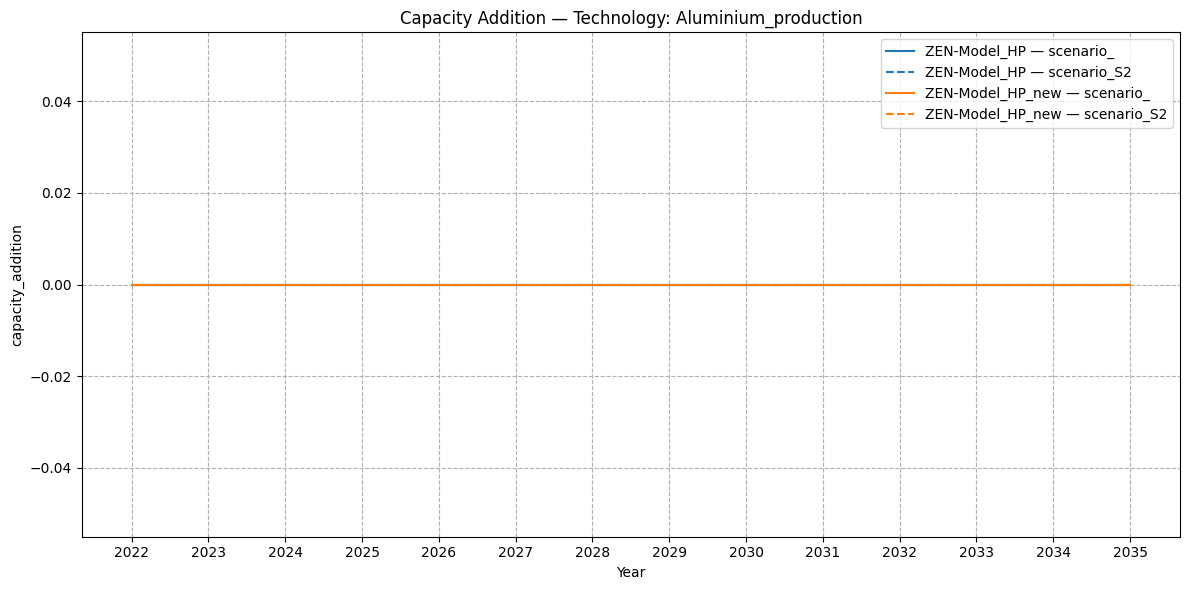

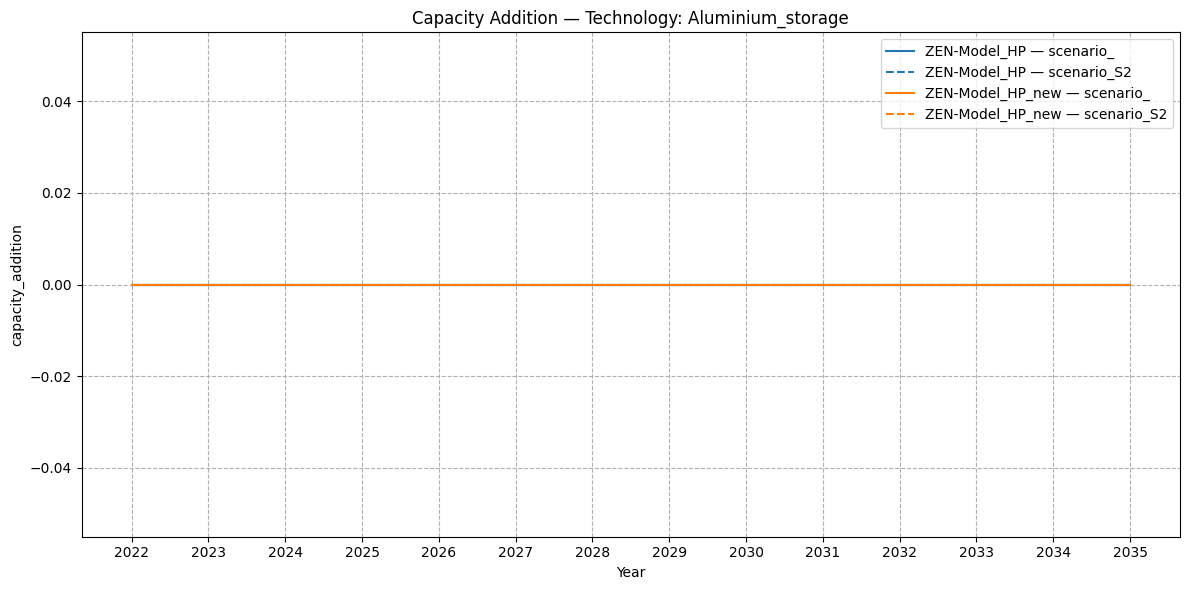

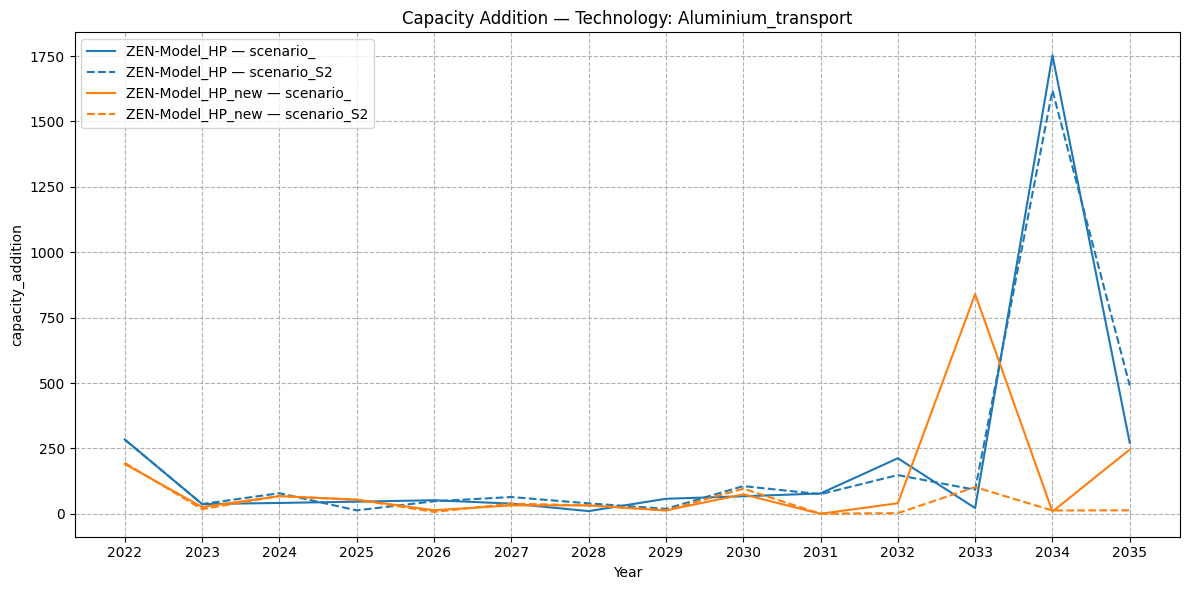

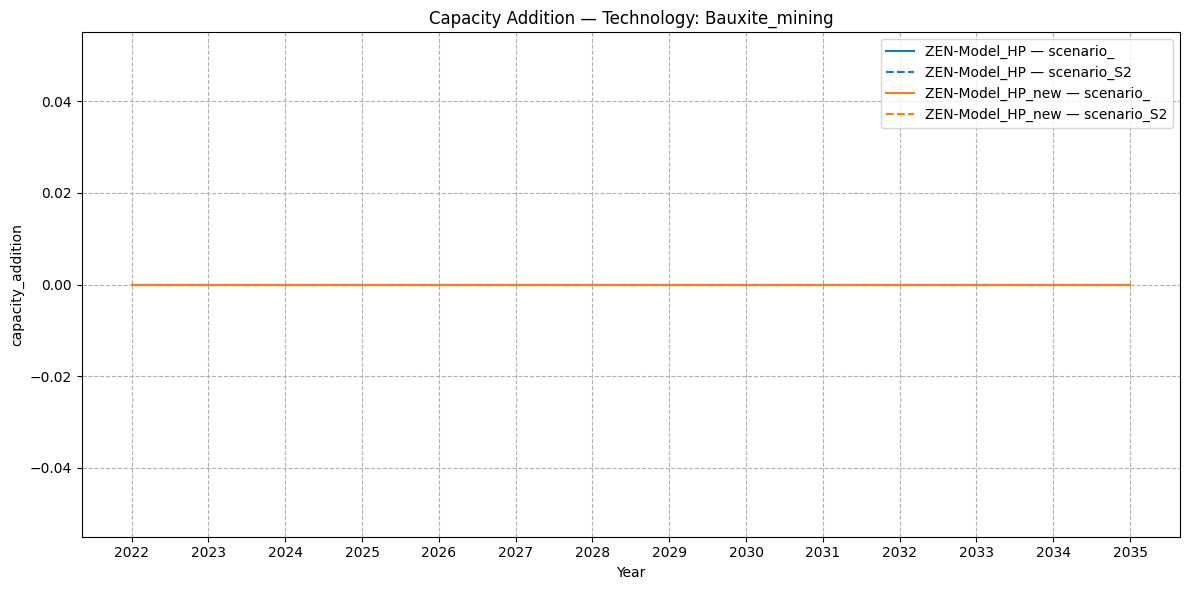

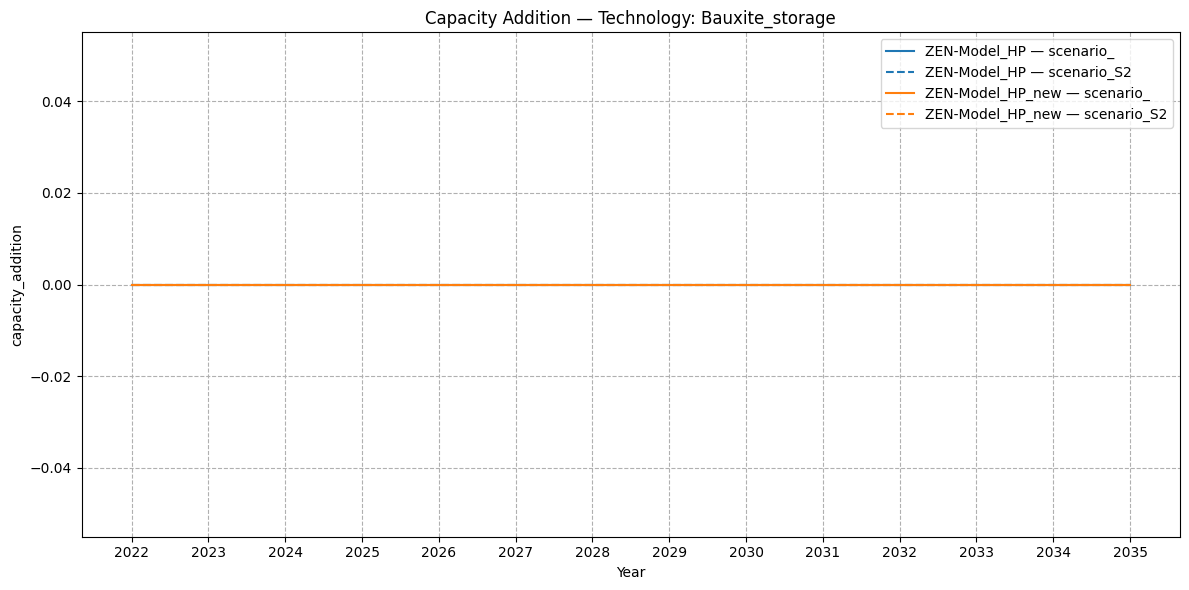

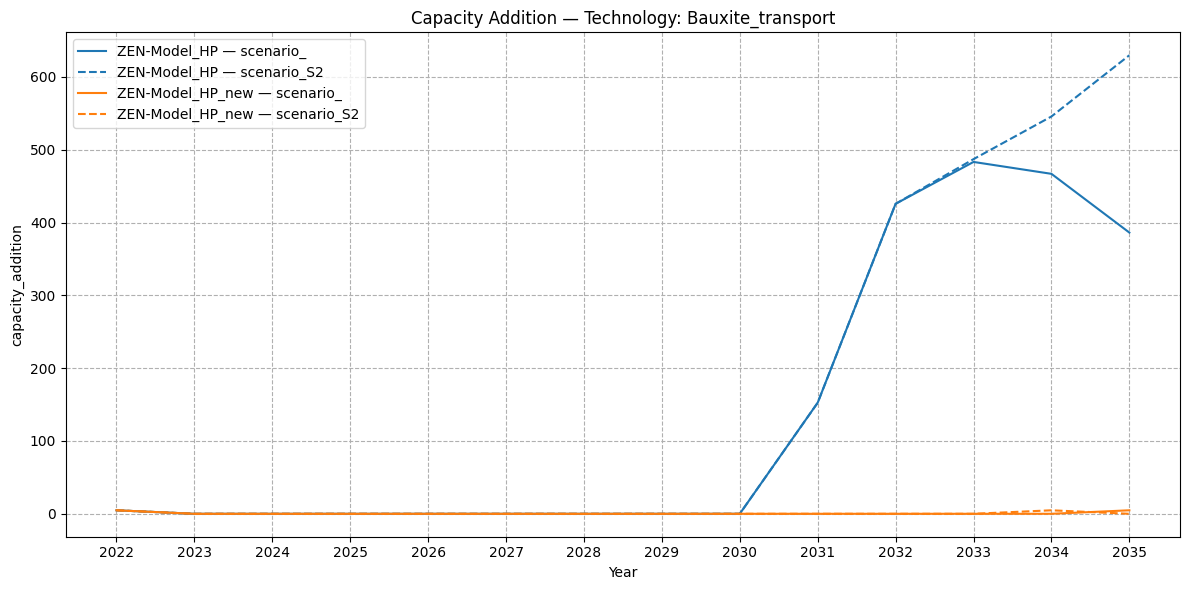

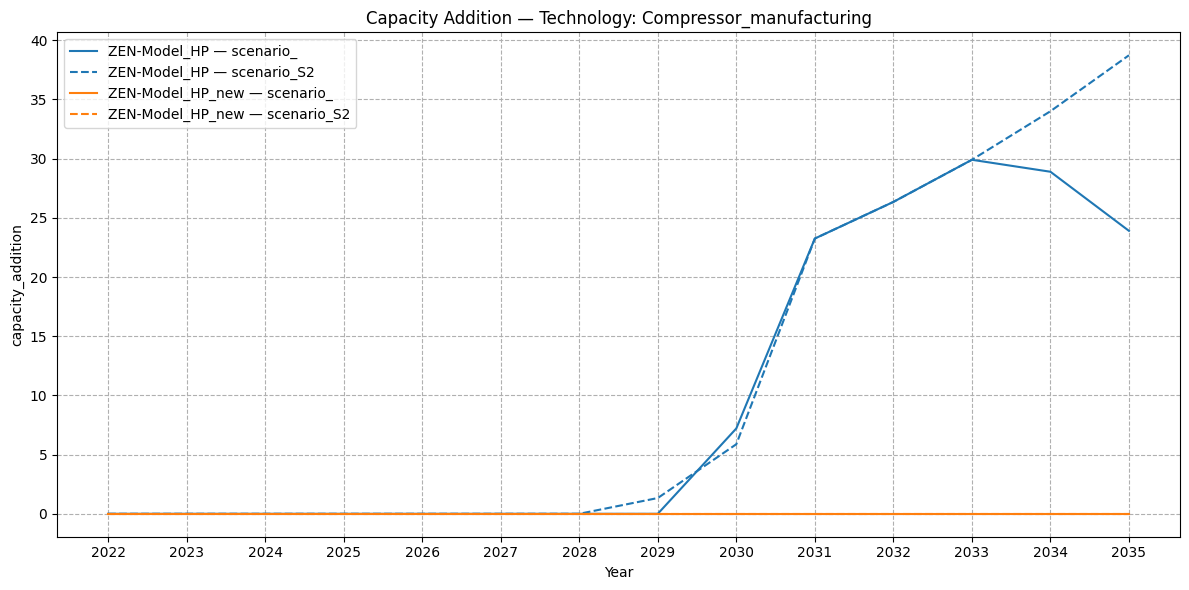

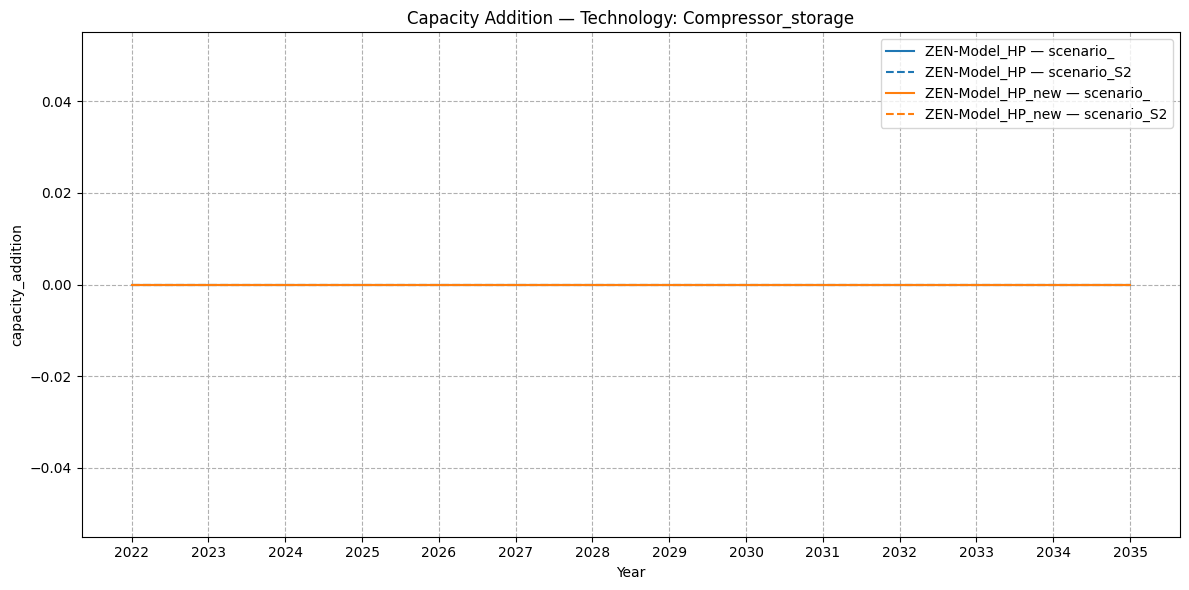

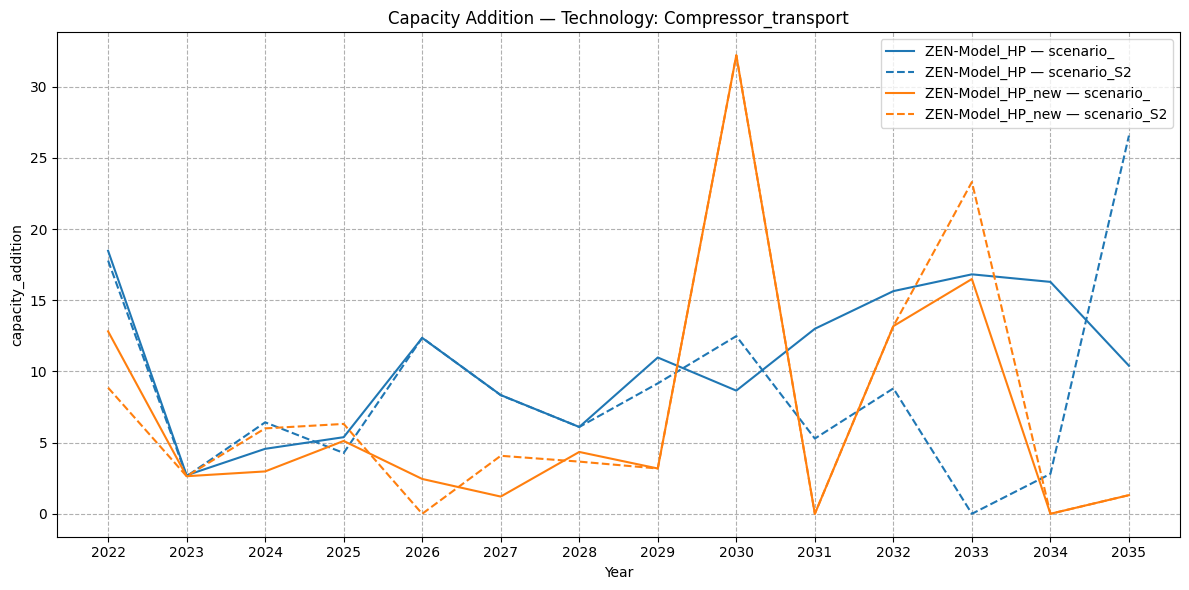

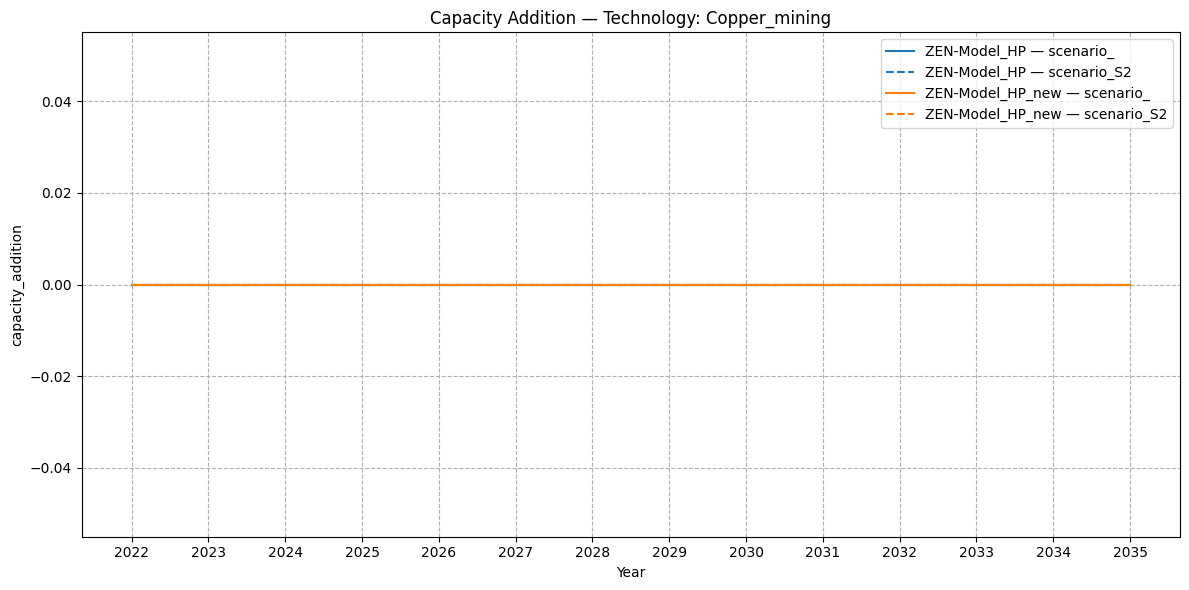

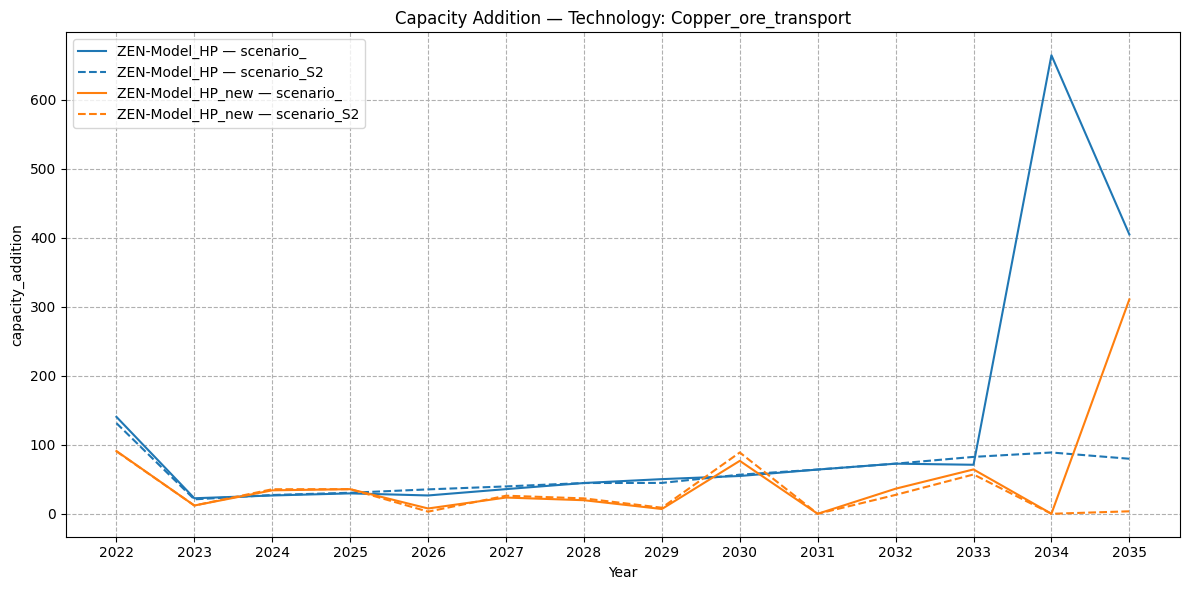

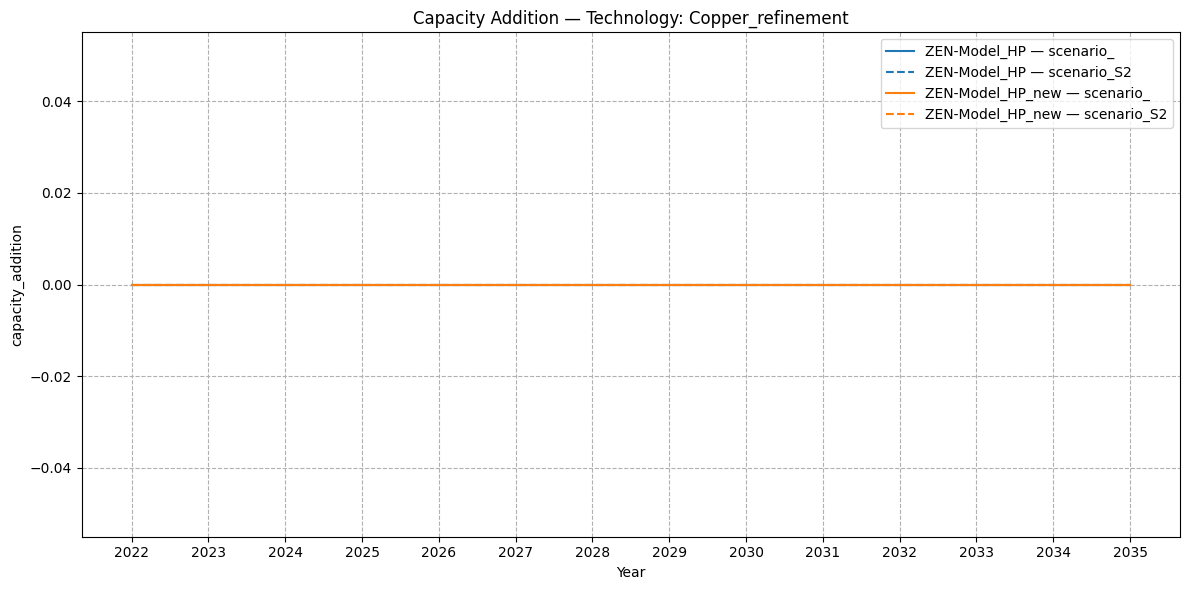

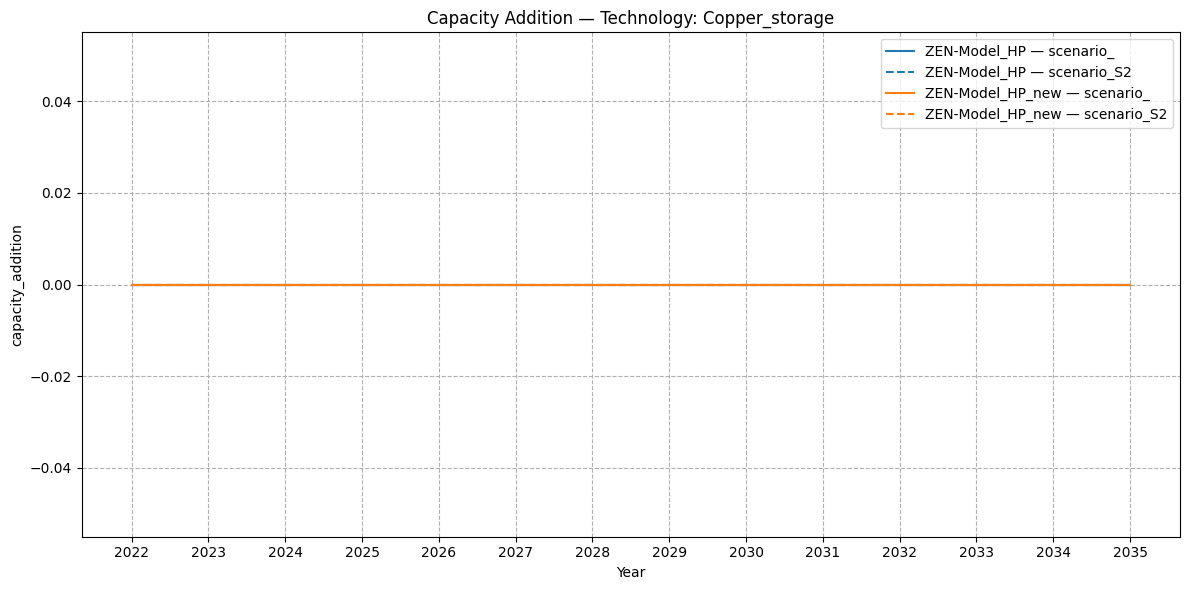

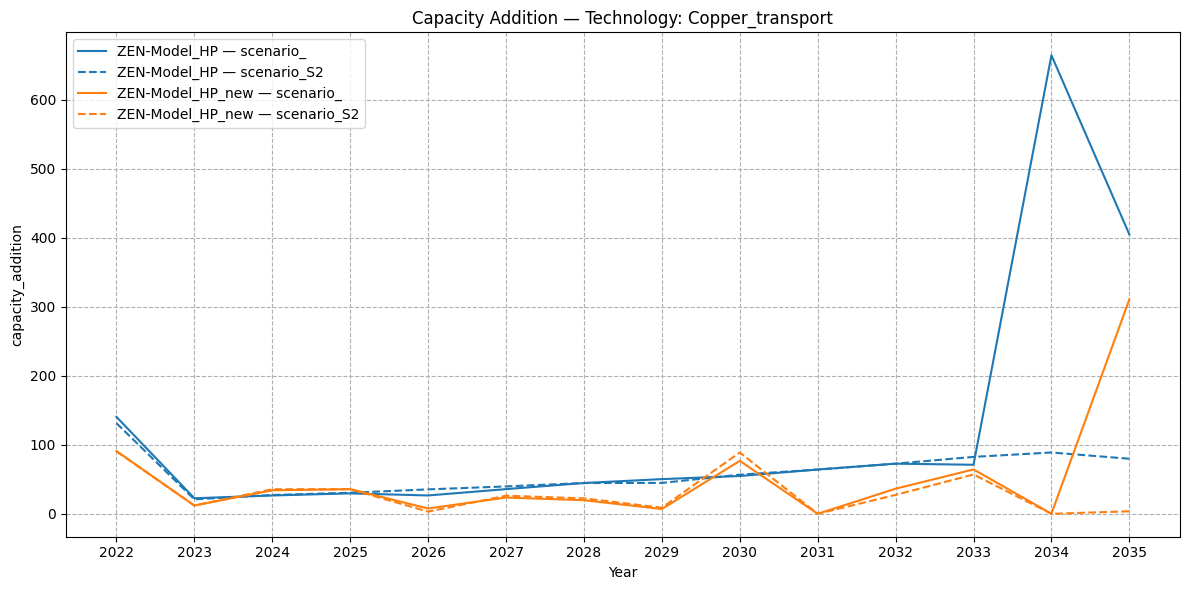

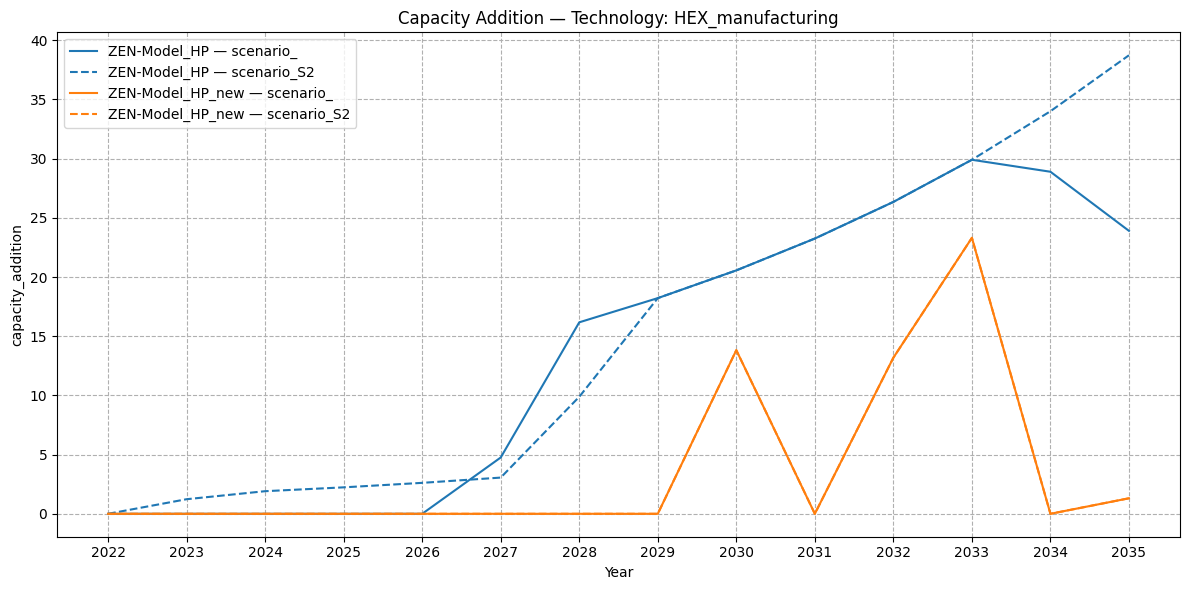

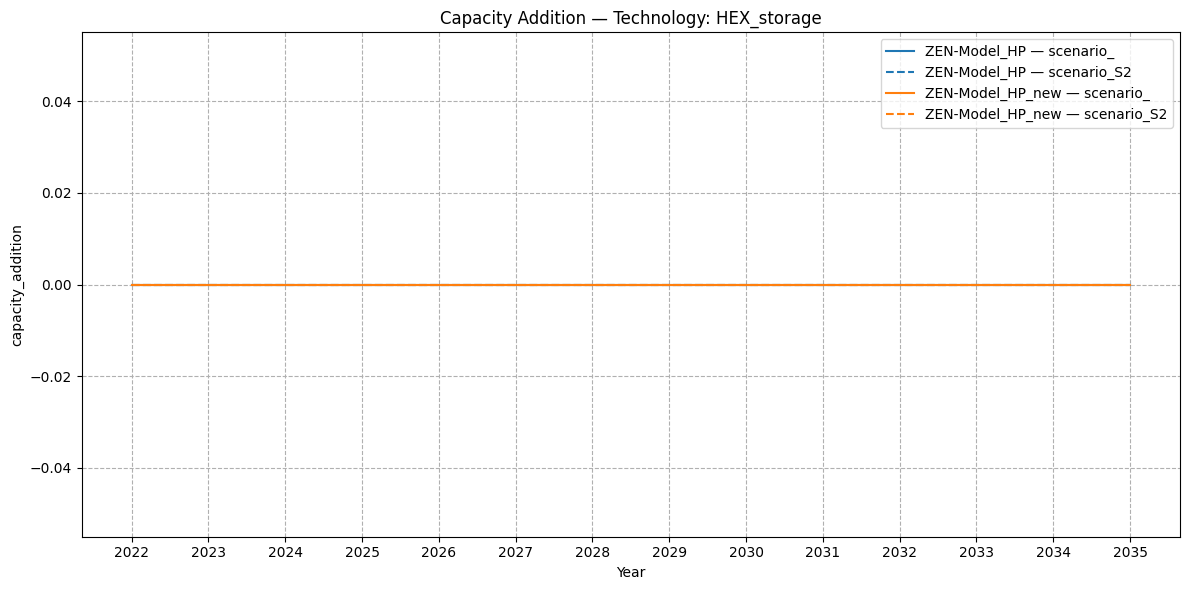

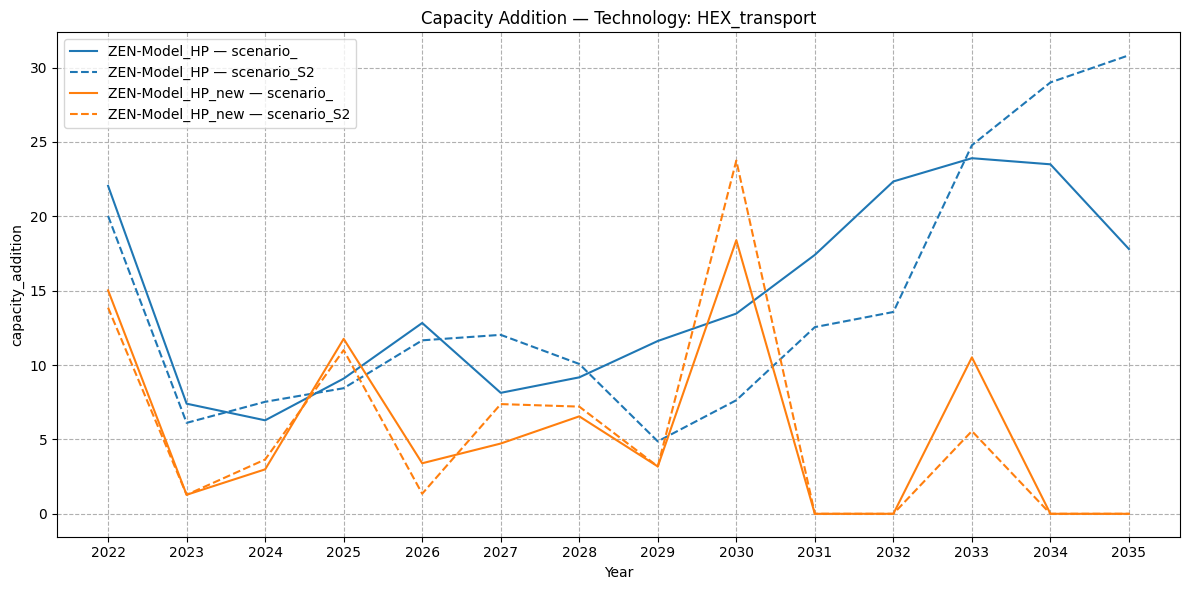

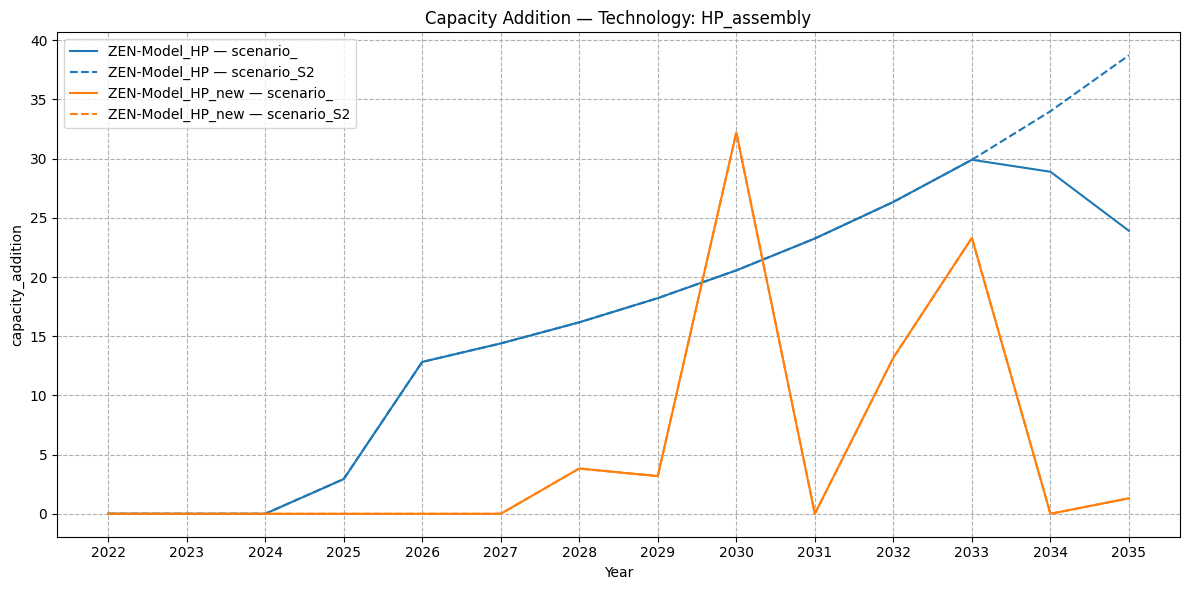

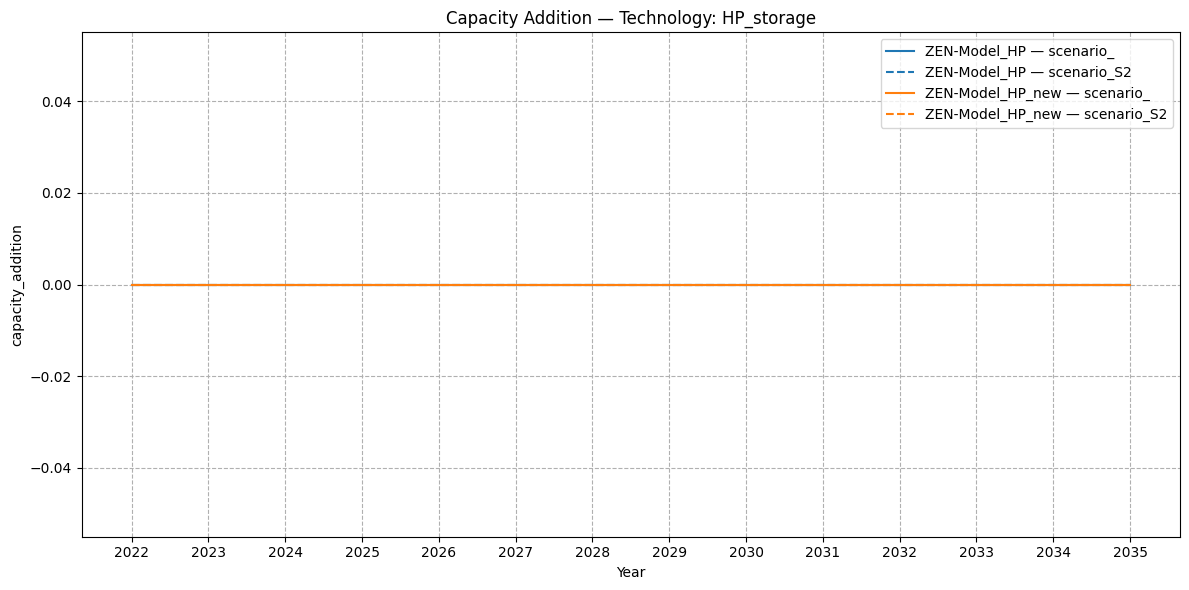

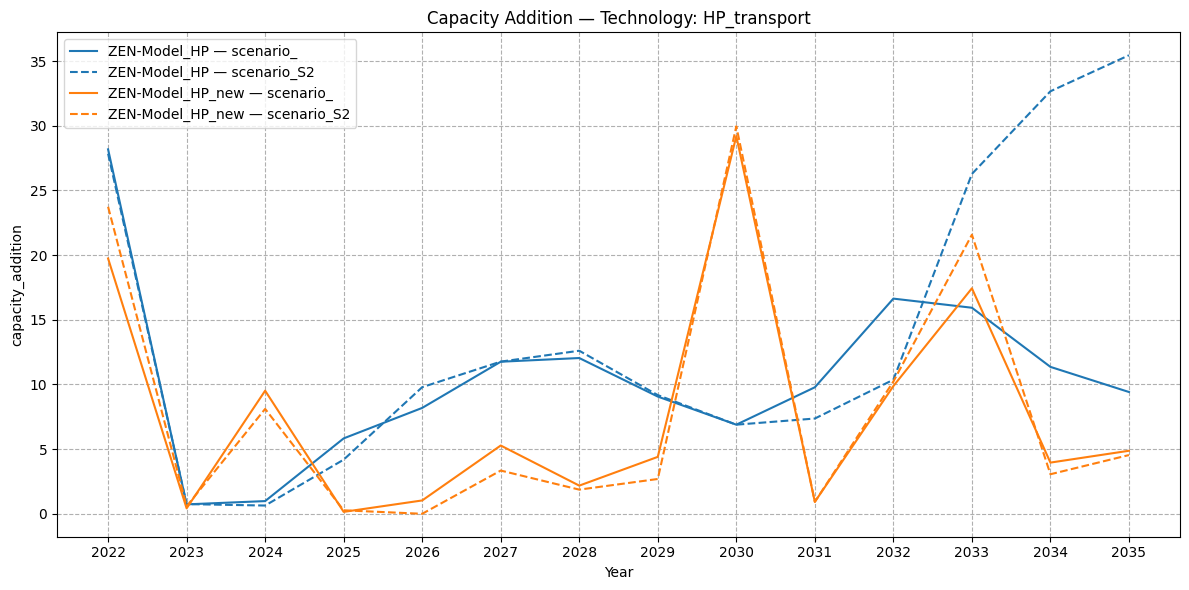

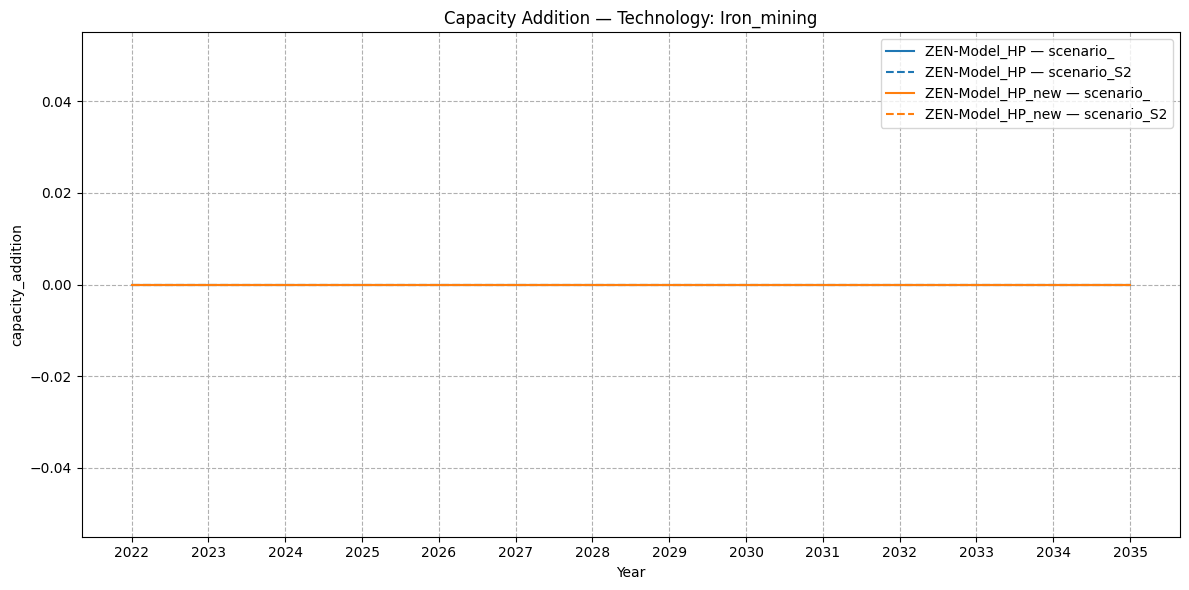

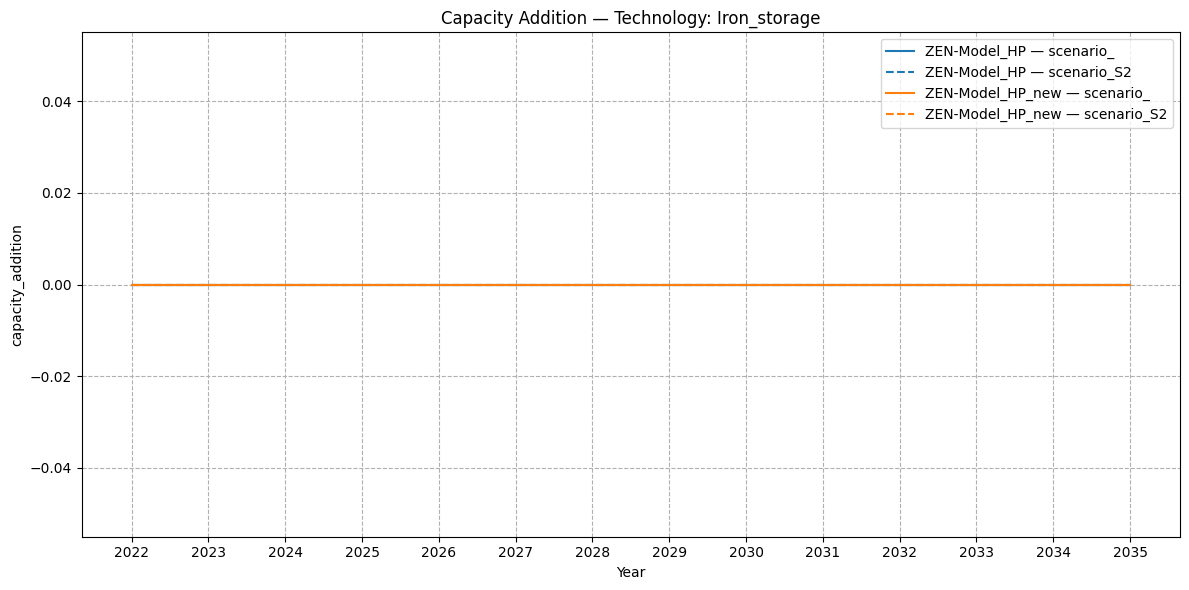

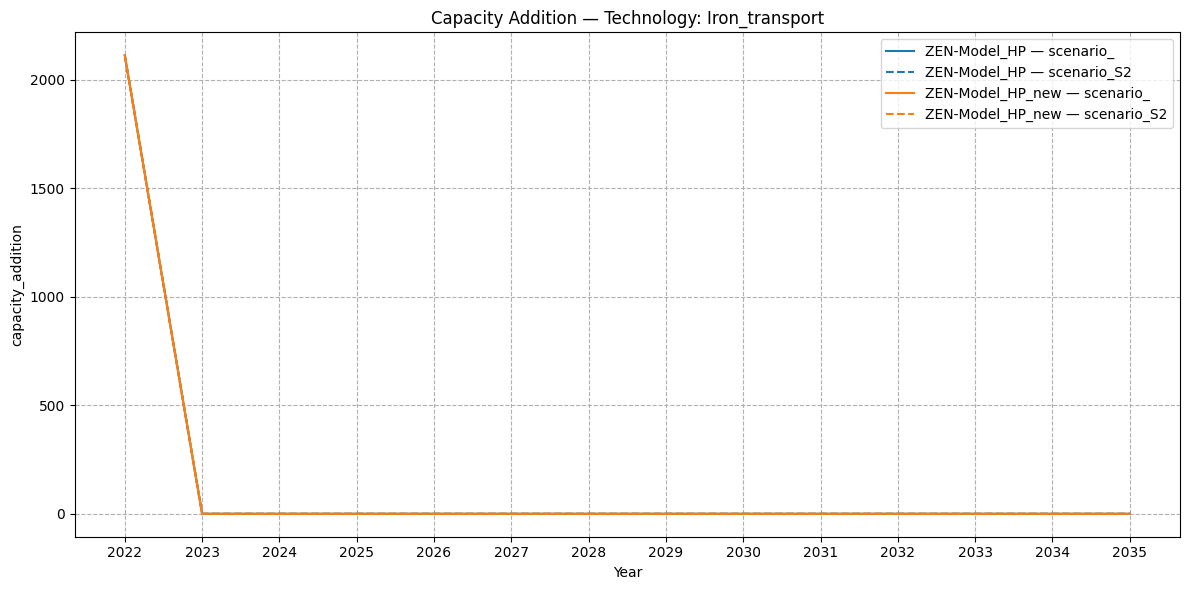

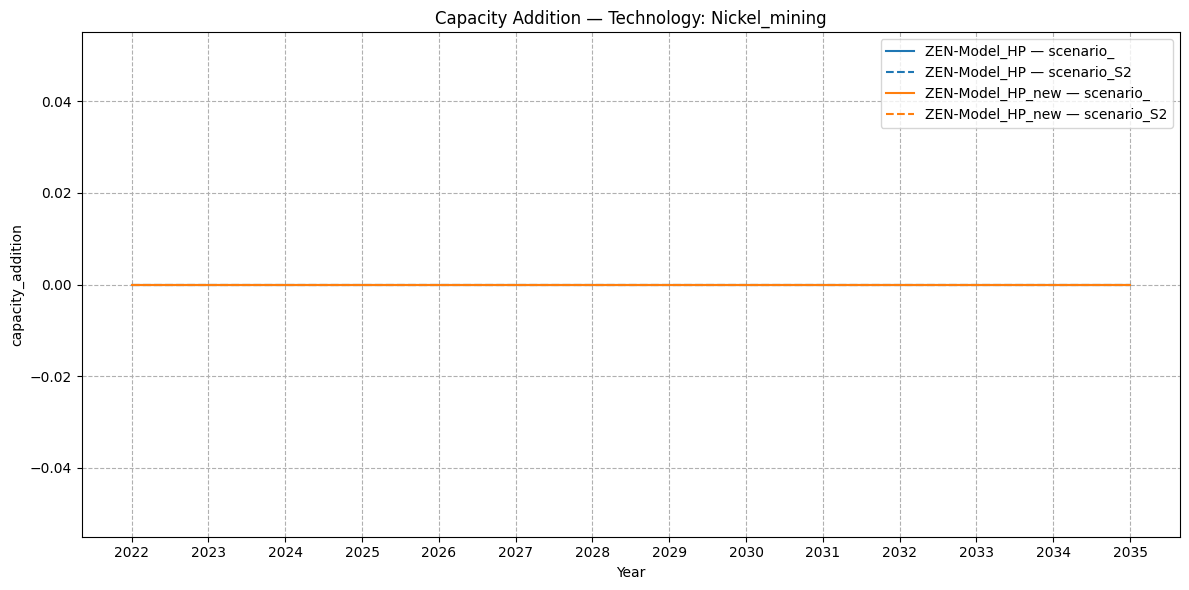

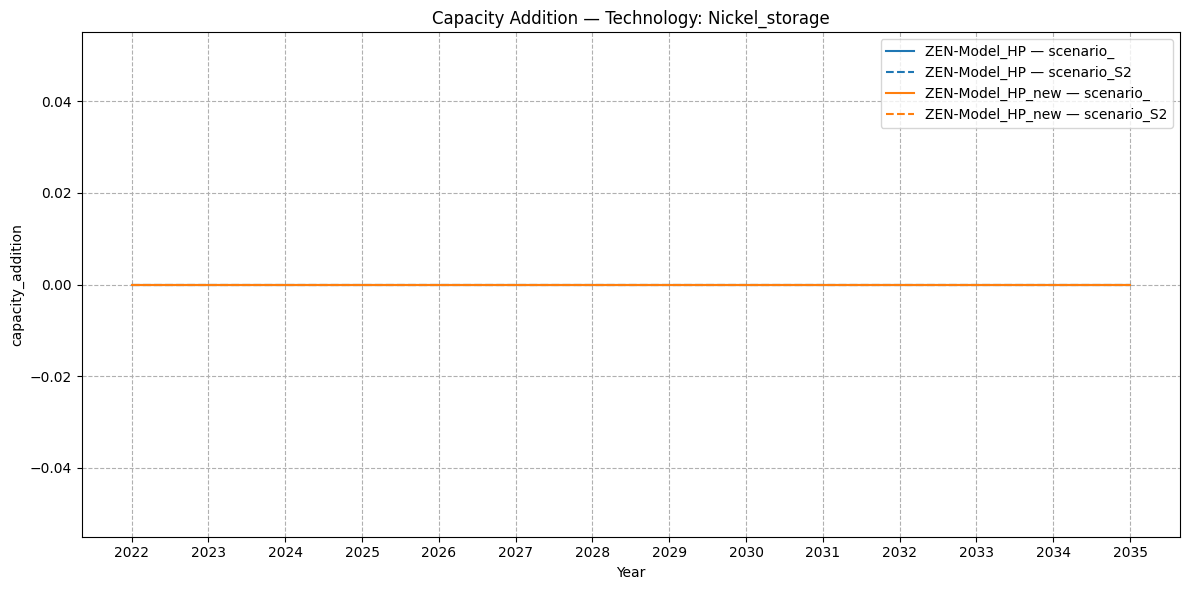

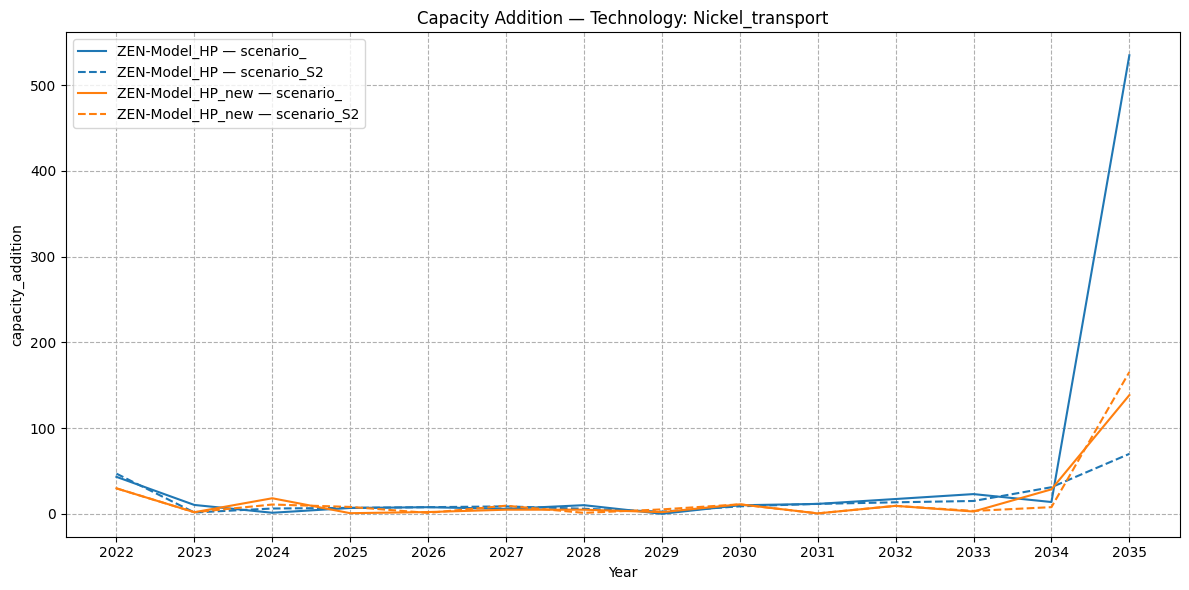

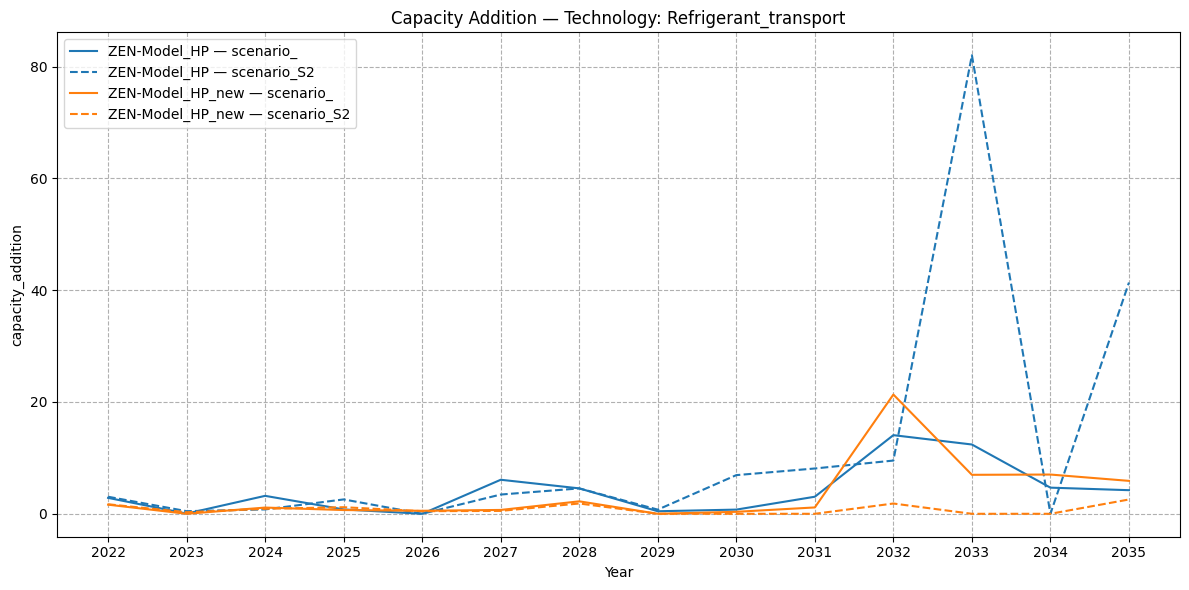

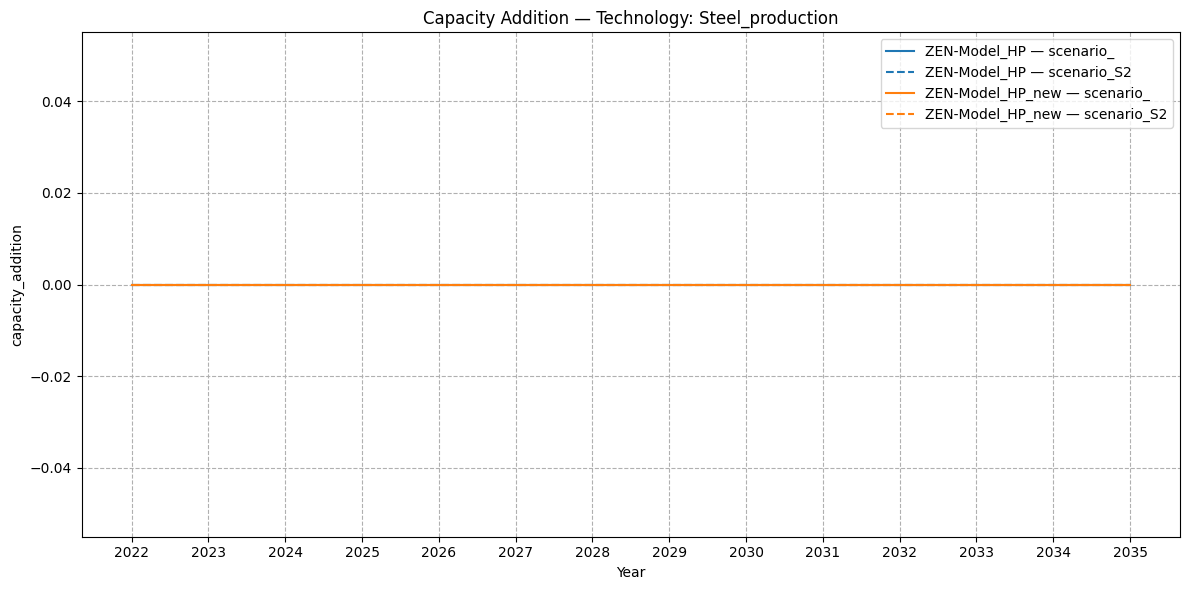

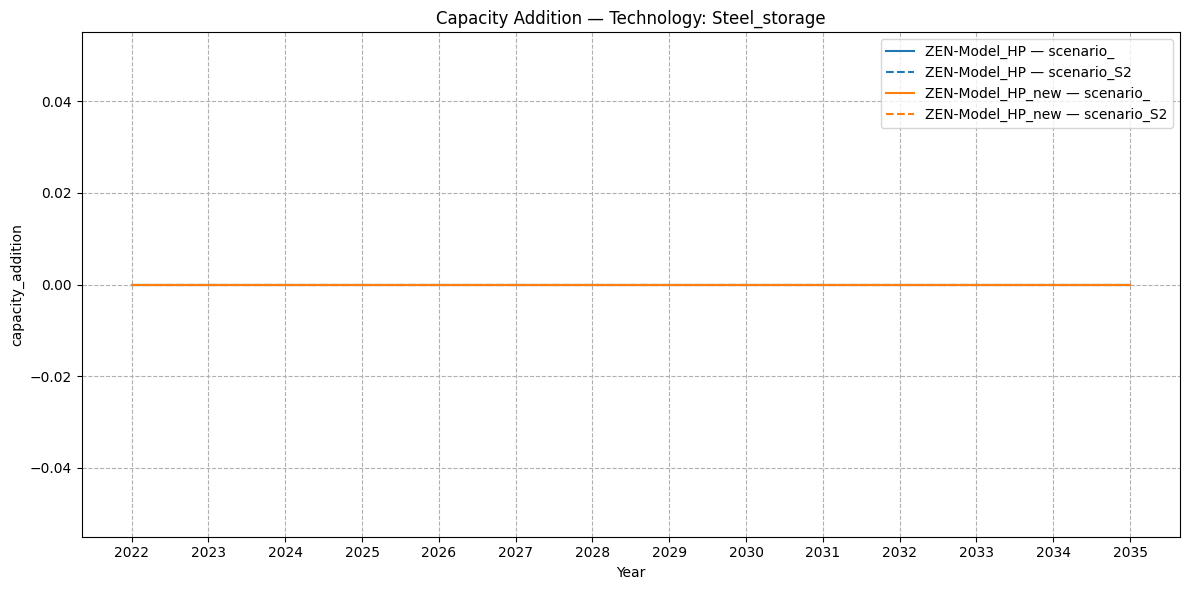

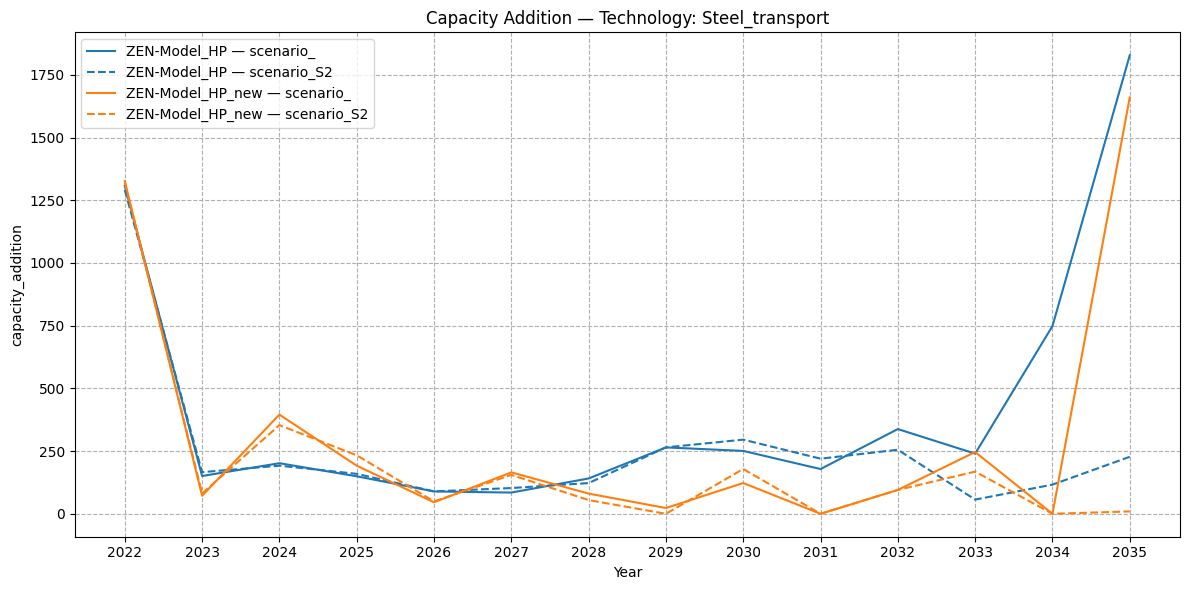

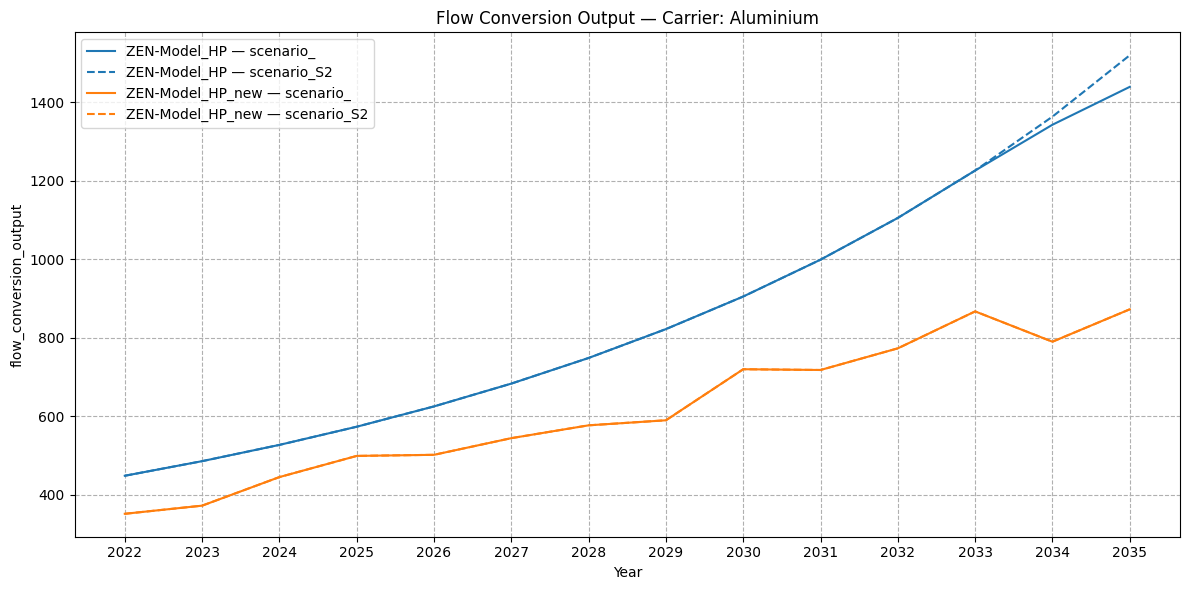

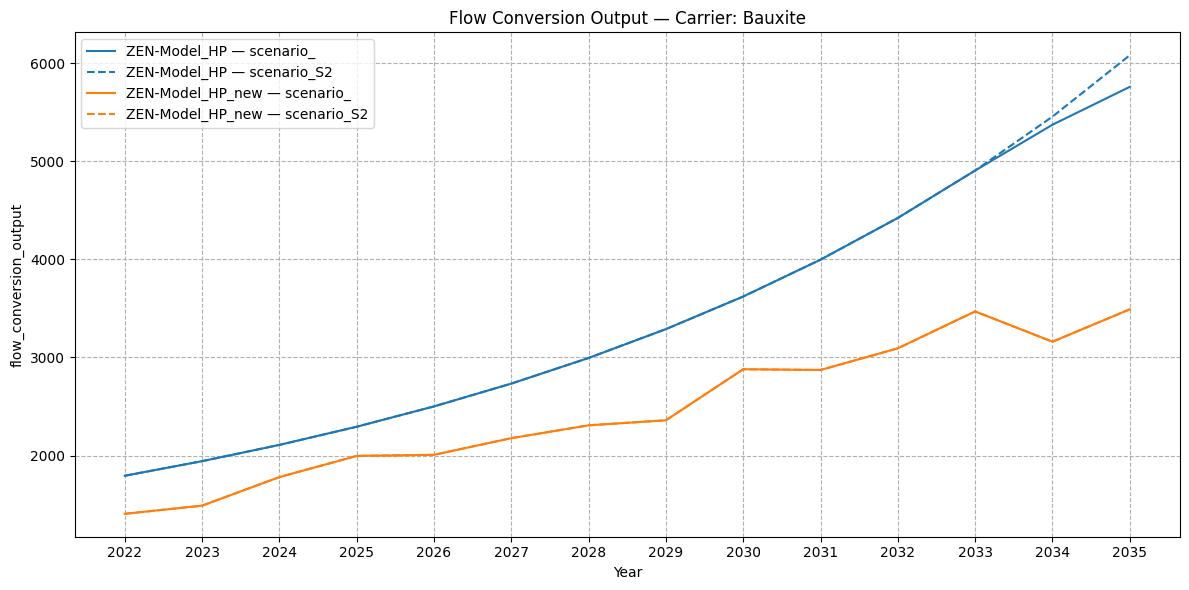

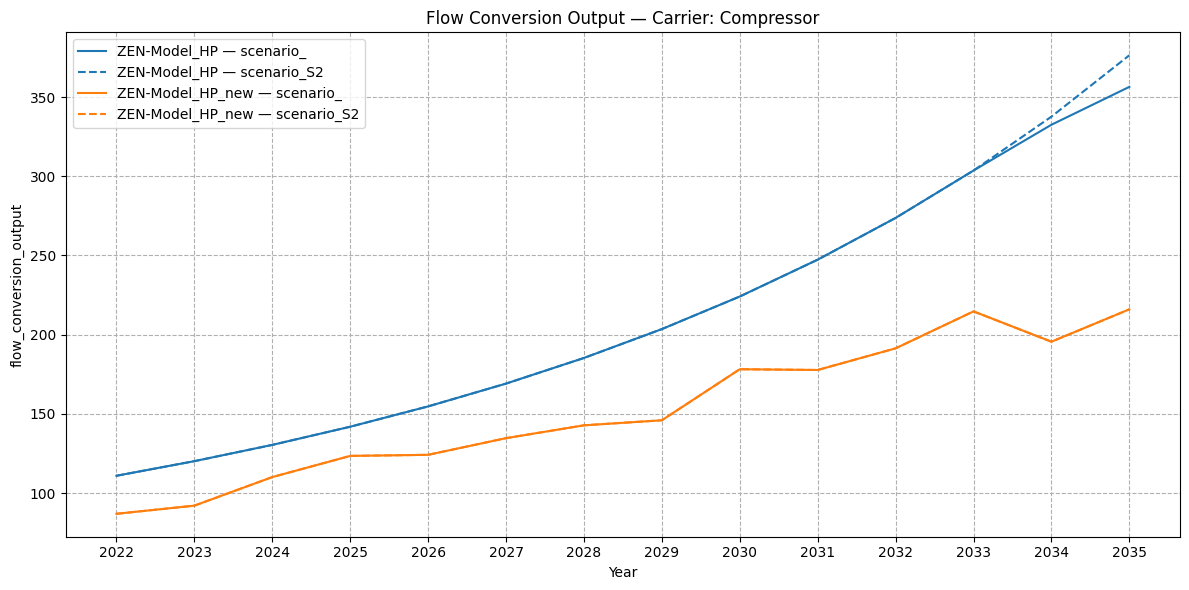

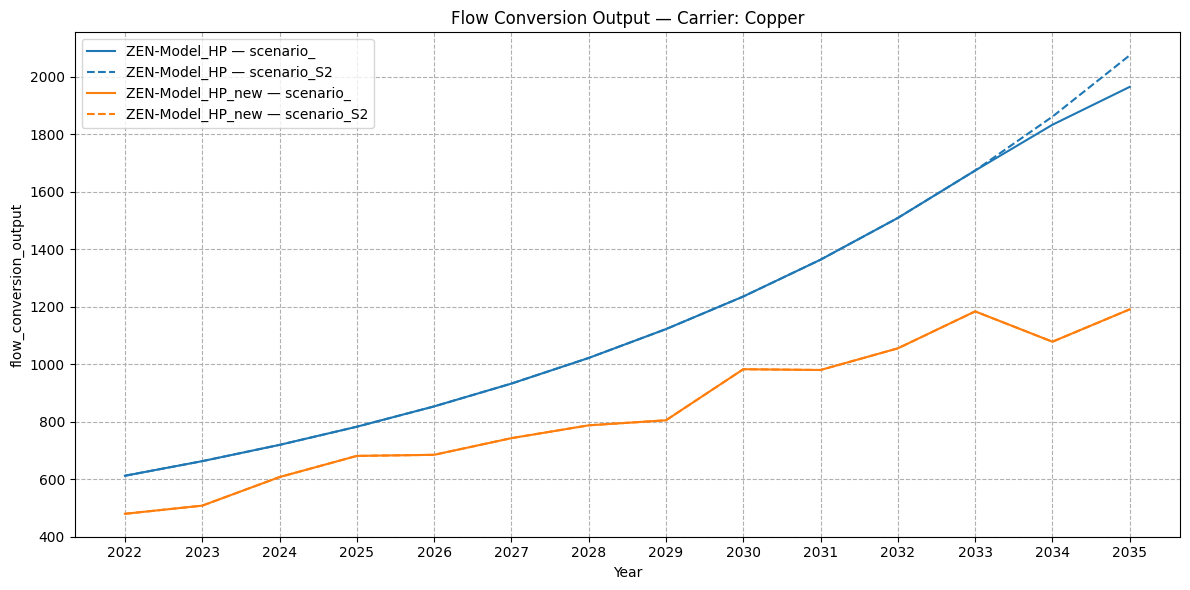

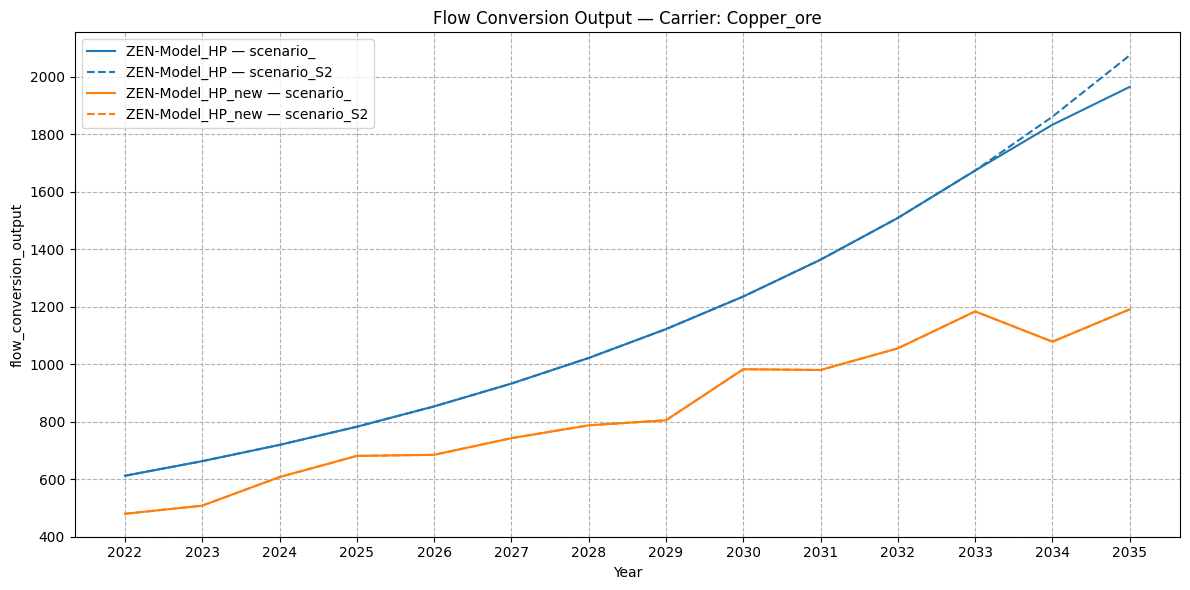

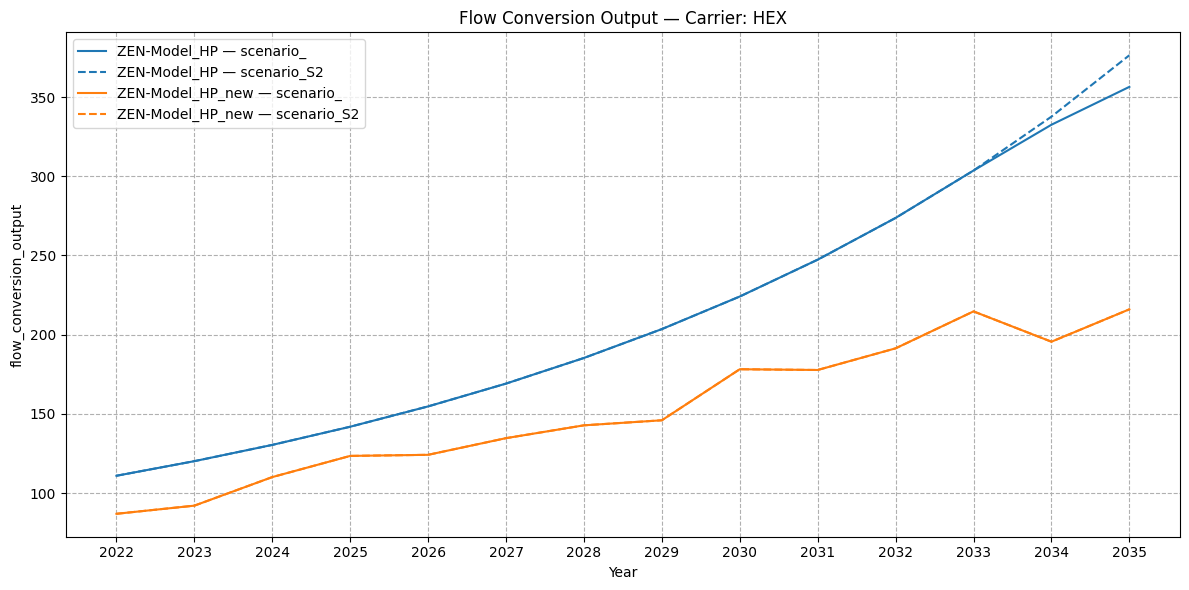

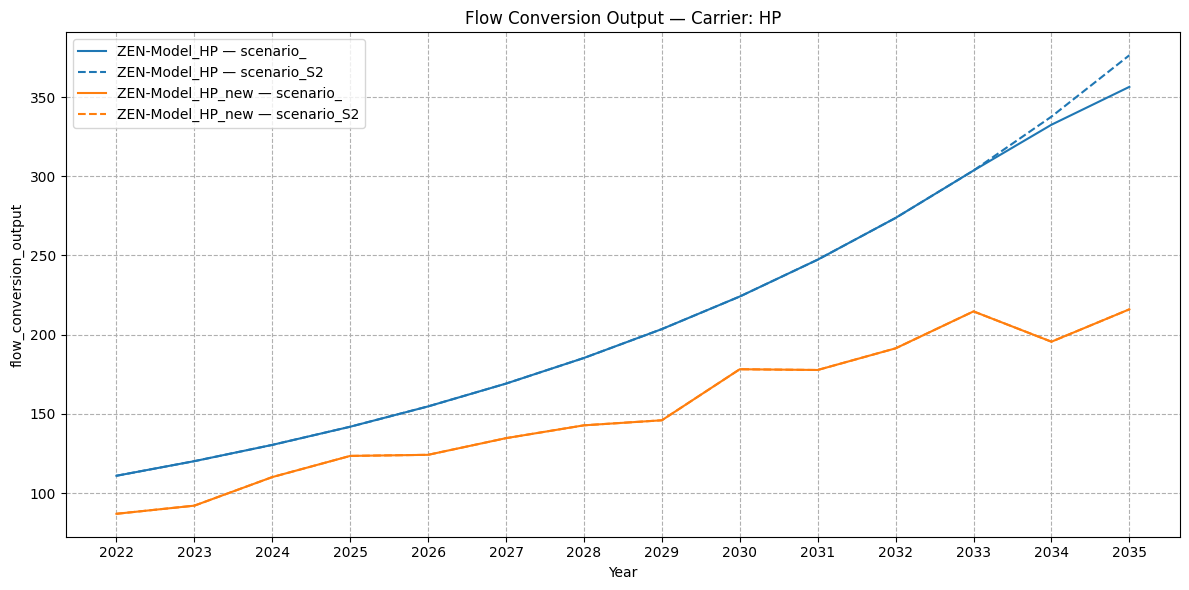

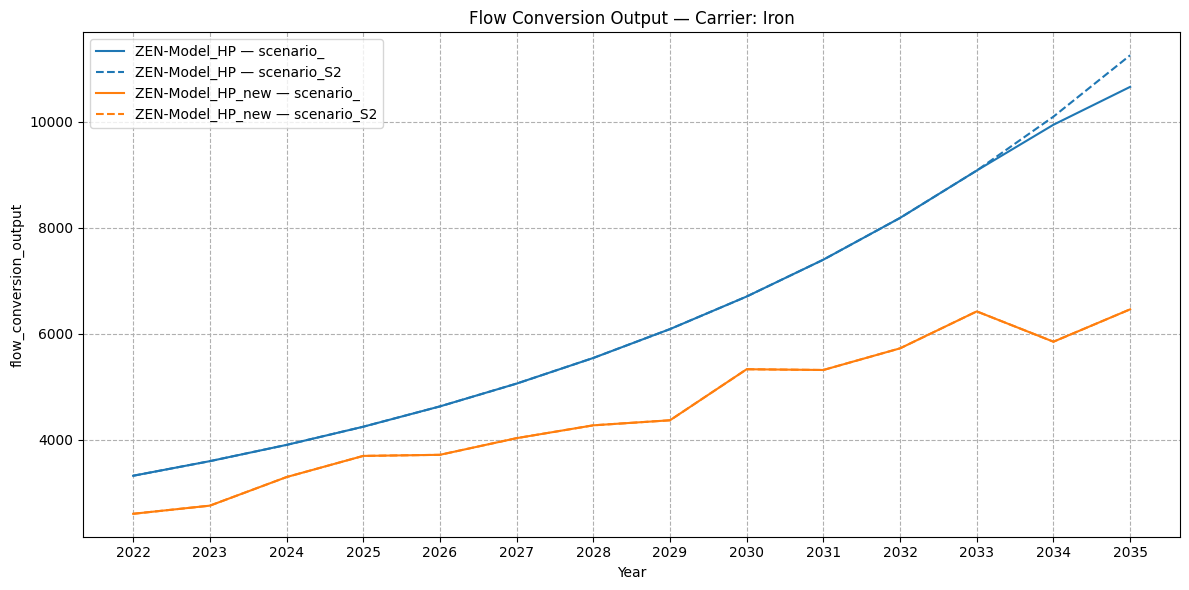

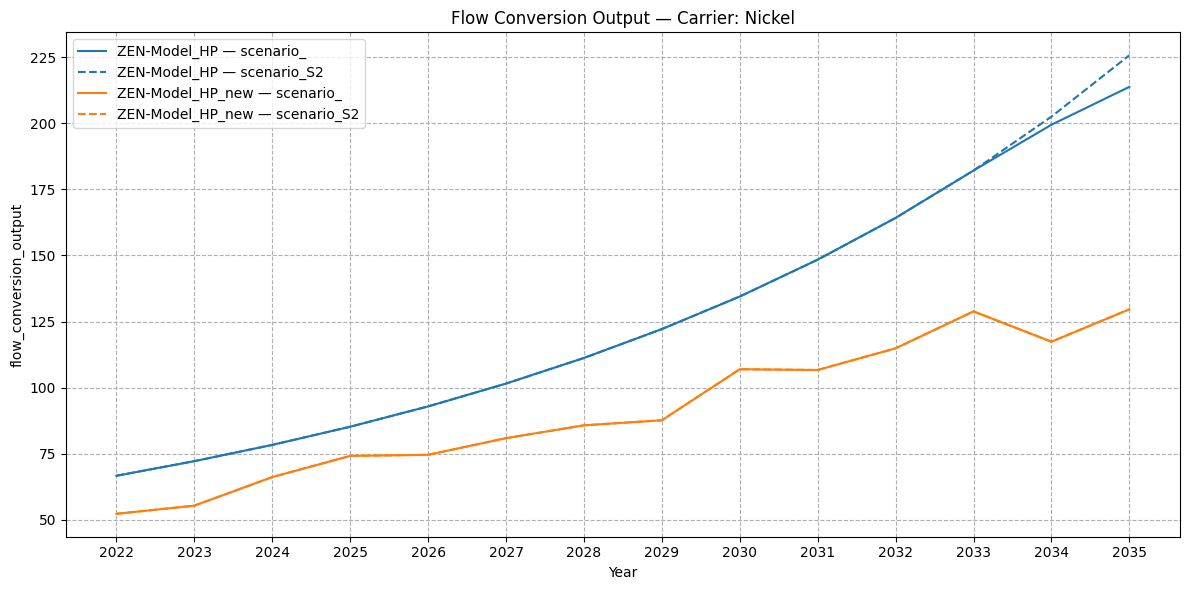

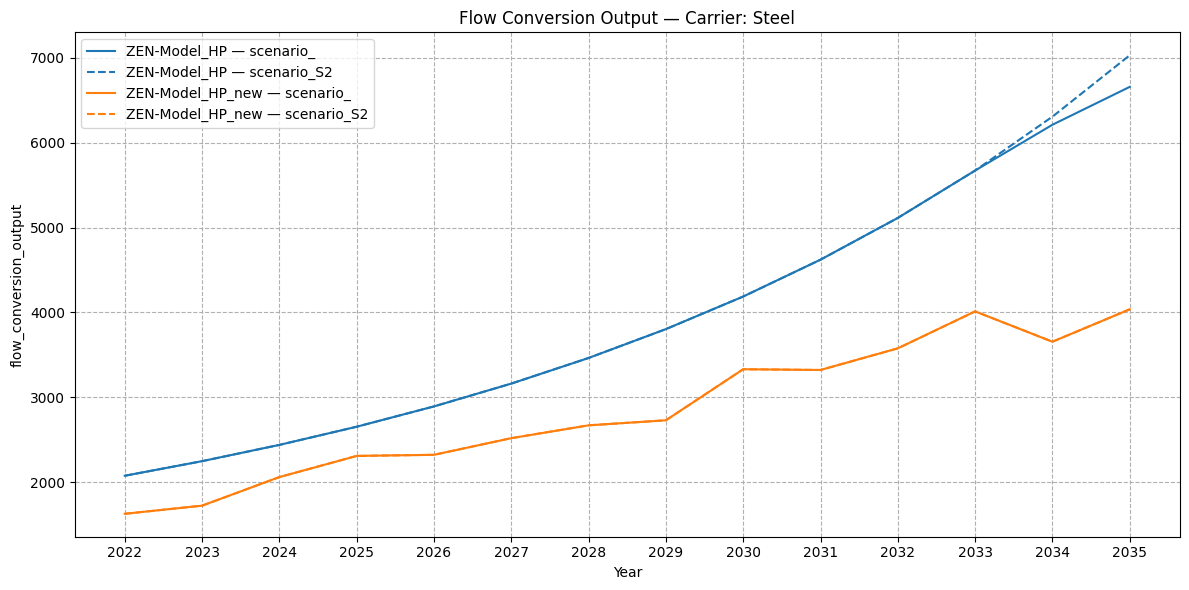

In [1]:
# script_multiindex_error.py

import os
import matplotlib.pyplot as plt
import pandas as pd
from zen_garden.postprocess.results import Results

dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

problematic_vars = [
'capacity_addition', 'flow_conversion_output', 'flow_export', 'flow_import',
    'flow_storage_charge', 'flow_storage_discharge', 'flow_transport', 'flow_transport_loss',
    'shed_demand', 'storage_level', 'technology_installation'
]

colors = {dataset_name_1: 'tab:blue', dataset_name_2: 'tab:orange'}
styles = {"scenario_": '-', "scenario_S2": '--'}

for var in problematic_vars:
    try:
        df1 = r1.get_full_ts(var).reset_index()
        df2 = r2.get_full_ts(var).reset_index()

        # Try to find the scenario
        scenario_col = next((col for col in ["level_0", "scenario", "run", "Run", "Scenario"] if col in df1.columns), None)
        if not scenario_col:
            print(f"⚠️ Skipping {var} — No scenario column")
            continue

        df1 = df1.rename(columns={scenario_col: "scenario"})
        df2 = df2.rename(columns={scenario_col: "scenario"})

        df1 = df1[df1["scenario"].isin(["scenario_", "scenario_S2"])]
        df2 = df2[df2["scenario"].isin(["scenario_", "scenario_S2"])]

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

        group_key = next((col for col in ["carrier", "node", "technology"] if col in df1.columns), None)
        if not group_key:
            print(f"⚠️ Skipping {var} — No group key (carrier/node/tech)")
            continue

        unique_keys = sorted(set(df1[group_key].unique()).union(df2[group_key].unique()))

        for key in unique_keys:
            df1_key = df1[df1[group_key] == key]
            df2_key = df2[df2[group_key] == key]

            grouped1 = df1_key.groupby("scenario")[time_cols].sum()
            grouped2 = df2_key.groupby("scenario")[time_cols].sum()

            plt.figure(figsize=(12, 6))
            for dataset_name, grouped in zip([dataset_name_1, dataset_name_2], [grouped1, grouped2]):
                for scenario in ["scenario_", "scenario_S2"]:
                    if scenario in grouped.index:
                        plt.plot(
                            time_cols,
                            grouped.loc[scenario],
                            label=f"{dataset_name} — {scenario}",
                            color=colors[dataset_name],
                            linestyle=styles[scenario]
                        )

            plt.title(f"{var.replace('_', ' ').title()} — {group_key.capitalize()}: {key}")
            plt.xlabel("Year")
            plt.ylabel(var)
            plt.grid(True, linestyle="--")
            plt.legend()
            plt.tight_layout()
            plt.xticks(ticks=time_cols, labels=[str(2022 + i) for i in range(len(time_cols))])
            plt.show()

    except Exception as e:
        print(f"⚠️ Error processing '{var}': {e}")
